In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from defects import *
import sys
import os
print(os.getcwd())

sys.path.insert(1, os.path.dirname(os.getcwd()))

c:\Users\victo\nematics\nematics\vasco_scripts


## Check for experimental example

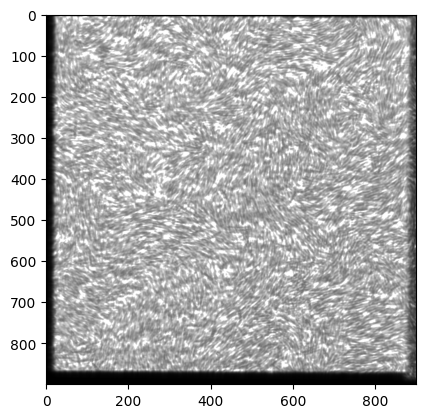

In [4]:
# data_path = r'C:\Users\USER'
# plot_path = r'D:\Scientific_data\Plots'

# # file = r'\4.jpg'
# file = r"\CODES\nematics\example_images\raw\1_X1.tif"
# file = r"\Downloads\BEER\pep 858\1-20\1-0001.tif"

# img = plt.imread(data_path + file)#[:,:900]
file = r"..\example_images\raw\1_X1.tif"
# file = r"\Downloads\BEER\pep 858\1-20\1-0001.tif"
# file = r"..\_bacteria\hbec_images\raw\Trans__281.tif"
# file = r"E:\BEER\March 1st 100fps 40X 50-50 1um gap\1_X1.tif"
# C:\Users\victo\nematics\nematics\example_images
# C:\Users\victo\nematics\nematics\_bacteria\hbec_images\raw

# TODO works only for reqtangular images.
img = plt.imread(file)[:,:900]
# img = img[-np.min(img.shape):,-np.min(img.shape):]
plt.imshow(img, cmap="gray")

## Giomi

In [5]:
ori, coh, E = orientation_analysis(img, 15)

# cv2.imwrite(r"C:\Users\victo\OneDrive - BGU\Desktop\test_ori.tif" ,ori)

Text(0, 0.5, 'y (in pixels)')

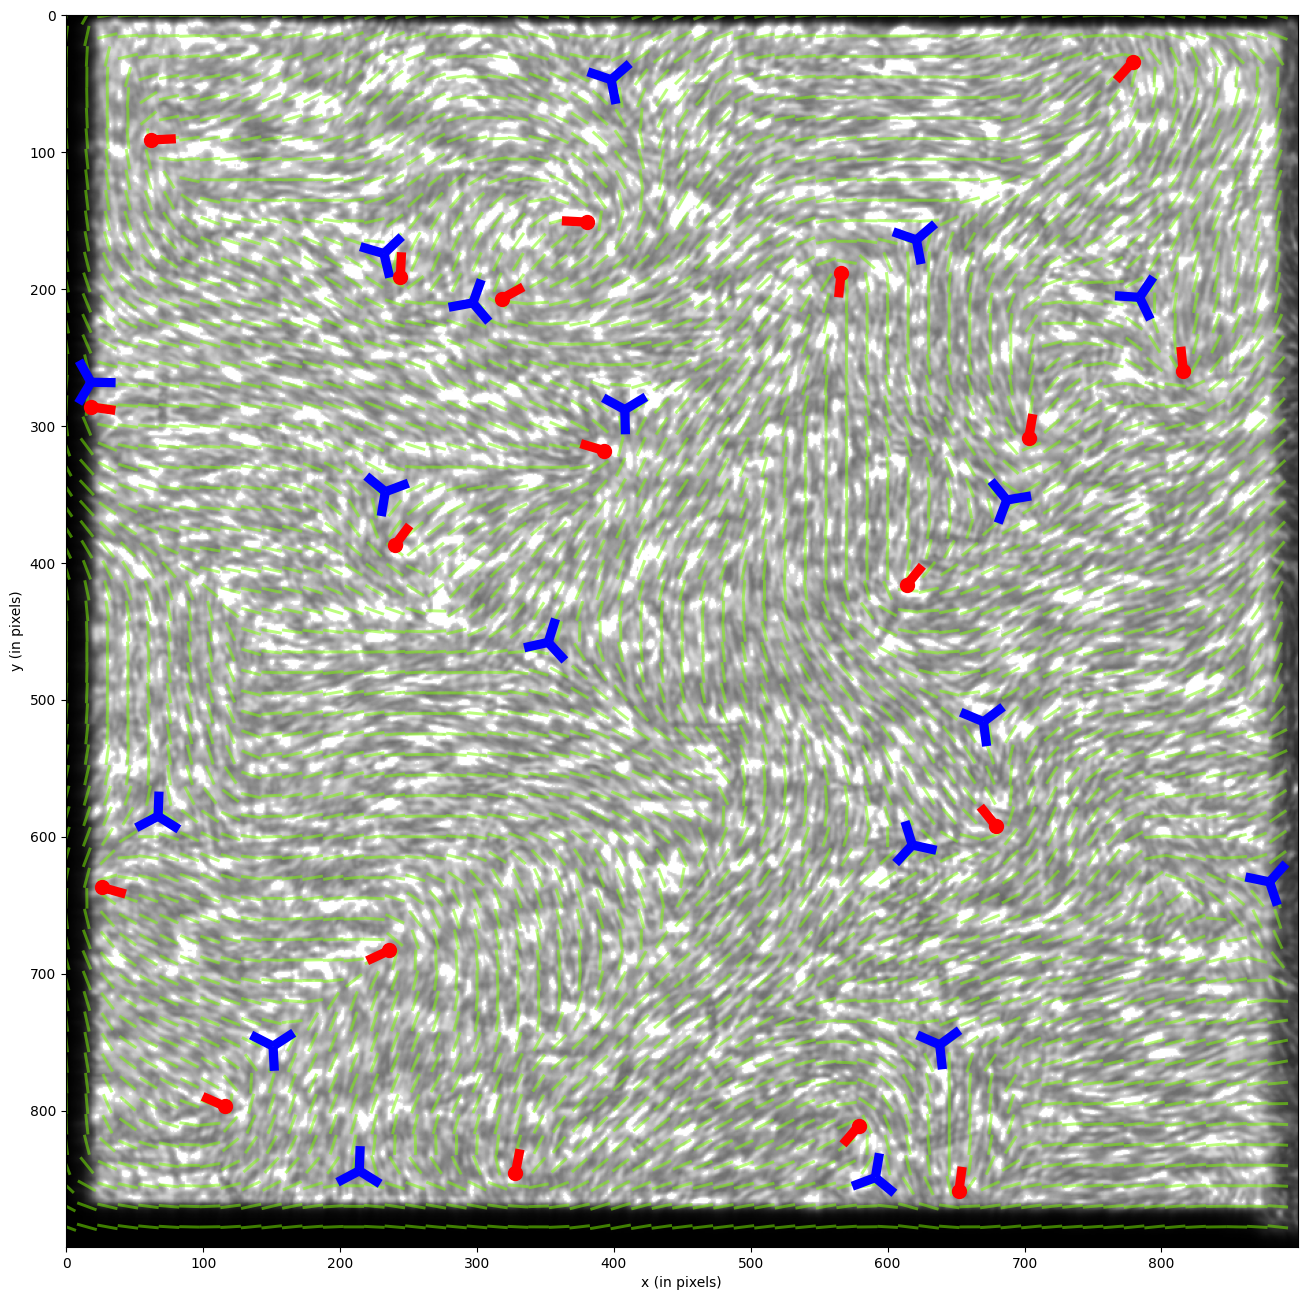

In [6]:
# Due to the choice of the 2x2 grid (neigbors in the northeastern corner), 
# we move the detected defect to the middle of the cell
shift = 1/2 
pix_x = img.shape[1]
pix_y = img.shape[0]

x = np.arange(0,pix_x)
y = np.arange(0,pix_y)

xx, yy = np.meshgrid(x, y)

ori, coh, E = orientation_analysis(img, 25)
k = compute_topological_charges(ori, int_area='cell', origin='upper')
defects = localize_defects(k, x_grid=xx, y_grid=yy)
compute_defect_orientations(ori, defects)
plushalf = defects[defects['charge']==.5]
minushalf = defects[defects['charge']==-.5]
fig, ax  = plt.subplots(figsize=(16,16))
s = 15
ax.imshow(img, cmap='gray')
ax.quiver(xx[::s,::s], yy[::s,::s], 
    np.cos(ori)[::s,::s], np.sin(ori)[::s,::s], 
    headaxislength=0, headwidth=0, headlength=0, 
    color='lawngreen', scale=60, pivot='mid', alpha=.5)

ax.plot(plushalf['x'], plushalf['y'],'ro',markersize=10,label=r'+1/2 defect')
ax.quiver(plushalf['x'], plushalf['y'], 
    np.cos(plushalf['ang1']), np.sin(plushalf['ang1']), 
    headaxislength=0, headwidth=0, headlength=0, color='r', scale=50)

for i in range(3):
    ax.quiver(minushalf['x'], minushalf['y'], 
        np.cos(minushalf['ang'+str(i+1)]), np.sin(minushalf['ang'+str(i+1)]), 
        headaxislength=0, headwidth=0, headlength=0, color='b', scale=50)

ax.set_xlabel('x (in pixels)')
ax.set_ylabel('y (in pixels)')

### Simple
The image (and all subsequent computations) have to be flipped in order to work properly. Maybe this can be streamlined/avoided by some additional keywords??

In [7]:
ori, coh, E = orientation_analysis(img, 25)
k = compute_topological_charges(-ori, int_area='cell', origin='lower')
defects = localize_defects(k, x_grid=xx, y_grid=yy)
compute_defect_orientations(-ori, defects, method='interpolation', x_grid=x, y_grid=y, interpolation_radius=5,  min_sep=1)

In [8]:
plushalf = defects[defects['charge']==.5]
minushalf = defects[defects['charge']==-.5]

Text(0, 0.5, 'y (in pixels)')

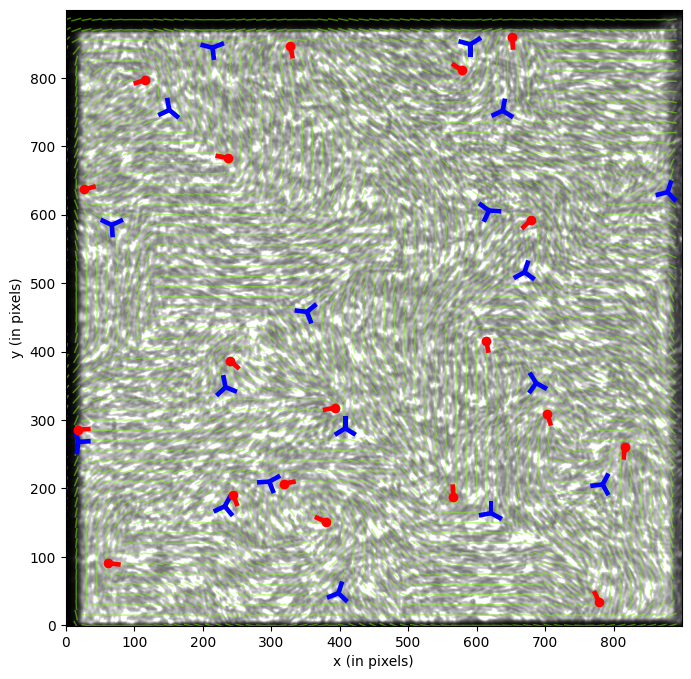

In [9]:
fig, ax  = plt.subplots(figsize=(8,8))
s = 15
ax.imshow(img, cmap='gray', origin='lower')
ax.quiver(xx[::s,::s], yy[::s,::s], 
    np.cos(ori)[::s,::s], -np.sin(ori)[::s,::s], 
    headaxislength=0, headwidth=0, headlength=0, 
    color='lawngreen', scale=60, pivot='mid', alpha=.5)

ax.plot(plushalf['x'], plushalf['y'],'ro',markersize=6,label=r'+1/2 defect')
ax.quiver(plushalf['x'], plushalf['y'], 
    np.cos(plushalf['ang1']), np.sin(plushalf['ang1']), 
    headaxislength=0, headwidth=0, headlength=0, color='r', scale=50)

for i in range(3):
    ax.quiver(minushalf['x'], minushalf['y'], 
        np.cos(minushalf['ang'+str(i+1)]), np.sin(minushalf['ang'+str(i+1)]), 
        headaxislength=0, headwidth=0, headlength=0, color='b', scale=50)

ax.set_xlabel('x (in pixels)')
ax.set_ylabel('y (in pixels)')

In [10]:
diff_1 = modulo(minushalf['ang1']-minushalf['ang2'],type='polar')
diff_2 = modulo(minushalf['ang1']-minushalf['ang3'],type='polar')
diff_3 = modulo(minushalf['ang2']-minushalf['ang3'],type='polar')
diff = np.hstack((diff_1,diff_2,diff_3))
np.rad2deg(diff)


array([ 115.2, -100.8,  111.6,  122.4,  -97.2, -158.4,  115.2, -122.4,
        151.2,  108. , -115.2, -111.6, -100.8,  122.4,  111.6, -104.4,
        104.4,  104.4, -129.6,  118.8, -144. , -126. ,  108. ,  100.8,
       -122.4,  115.2, -111.6, -133.2,  136.8,  118.8,  147.6, -118.8,
       -126. ,  140.4, -144. , -122.4,  115.2, -140.4,  104.4,  111.6,
       -154.8, -100.8,  122.4, -122.4,   97.2,  118.8, -108. , -129.6,
       -111.6,  118.8,  122.4, -115.2,  111.6,  133.2])

Text(0, 0.5, 'PDF')

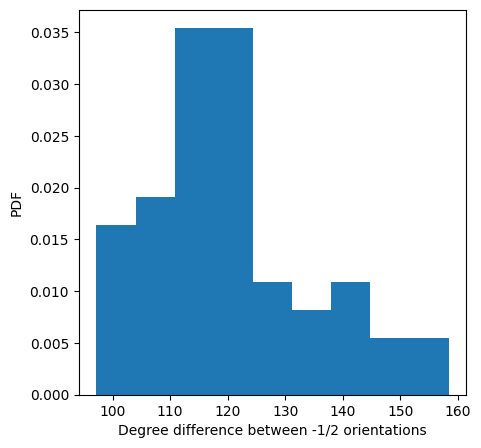

In [11]:
fig, ax = plt.subplots(figsize=(5,5))
ax.hist(np.abs(np.rad2deg(diff)),bins='auto',density=True)
ax.set_xlabel('Degree difference between -1/2 orientations')
ax.set_ylabel('PDF')

In [12]:
print(np.argmin(diff_1))
print(np.argmin(diff_2))
print(np.argmin(diff_3))

5
2
4


In [13]:
print(np.rad2deg(diff_1[1]))
print(np.rad2deg(diff_2[1]))
print(np.rad2deg(diff_3[1]))

-100.79999999999998
118.80000000000001
-140.4


## Check consistency of quiver/imshow

In [14]:
-np.min(img.shape)

np.int64(-900)

In [15]:
data_path = r'C:\Users\USER'
plot_path = r'D:\Scientific_data\Plots'

# file = r'\4.jpg'
# file = r"\CODES\nematics\example_images\raw\1_X1.tif"
file = r"..\example_images\raw\1_X1.tif"


# TODO works only for reqtangular images.
img = plt.imread(file)[:900,:900]
# img = img[-np.min(img.shape):,-np.min(img.shape):]

from skimage.color import rgb2gray
img = rgb2gray(img)
plt.imshow(img, cmap="gray")

ValueError: the input array must have size 3 along `channel_axis`, got (900, 900)

In [16]:
shift = 1/2 # Due to the choice of the 2x2 grid (neigbors in the northeastern corner), we move the detected defect to the middle of the cell

pix_x = img.shape[1]
pix_y = img.shape[0]

x = np.arange(0,pix_x)
y = np.arange(0,pix_y)

xx, yy = np.meshgrid(x, y)

In [17]:
ori, coh, E = orientation_analysis(img, 15)
k = compute_topological_charges(ori, int_area='cell', origin='upper')
defects = localize_defects(k, x_grid=xx, y_grid=yy)
compute_defect_orientations(ori, defects)

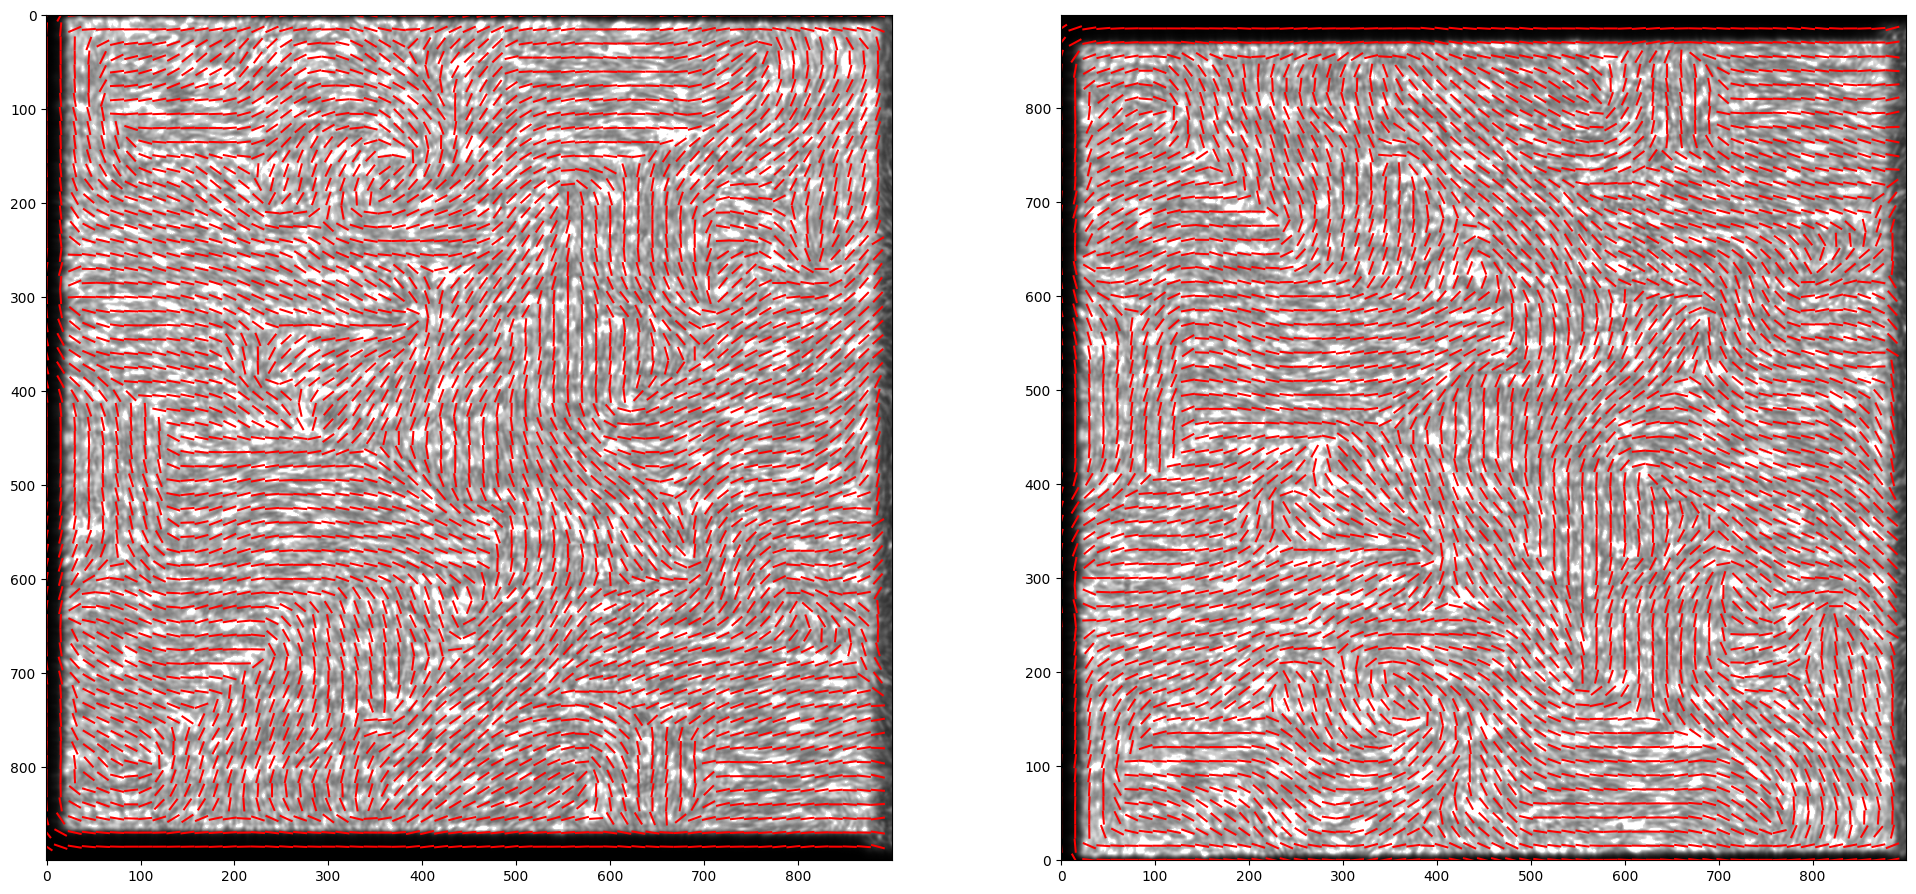

In [18]:
fig, axs  = plt.subplots(1,2,figsize=(24,12))
s = 15
axs[0].imshow(img,cmap='gray')
axs[0].quiver(xx[::s,::s], yy[::s,::s], 
    np.cos(ori)[::s,::s], np.sin(ori)[::s,::s], 
    headaxislength=0, headwidth=0, headlength=0, color='r', scale=60, pivot='mid')
axs[1].imshow(img,cmap='gray',origin='lower')
axs[1].quiver(xx[::s,::s], yy[::s,::s], 
    np.cos(-ori)[::s,::s], np.sin(-ori)[::s,::s], 
    headaxislength=0, headwidth=0, headlength=0, color='r', scale=60, pivot='mid')

## Analytical examples
Symmetric defects as minimizers of elastic energy (equal Frank constants)

0.5000000000000001


ValueError: x must be strictly increasing

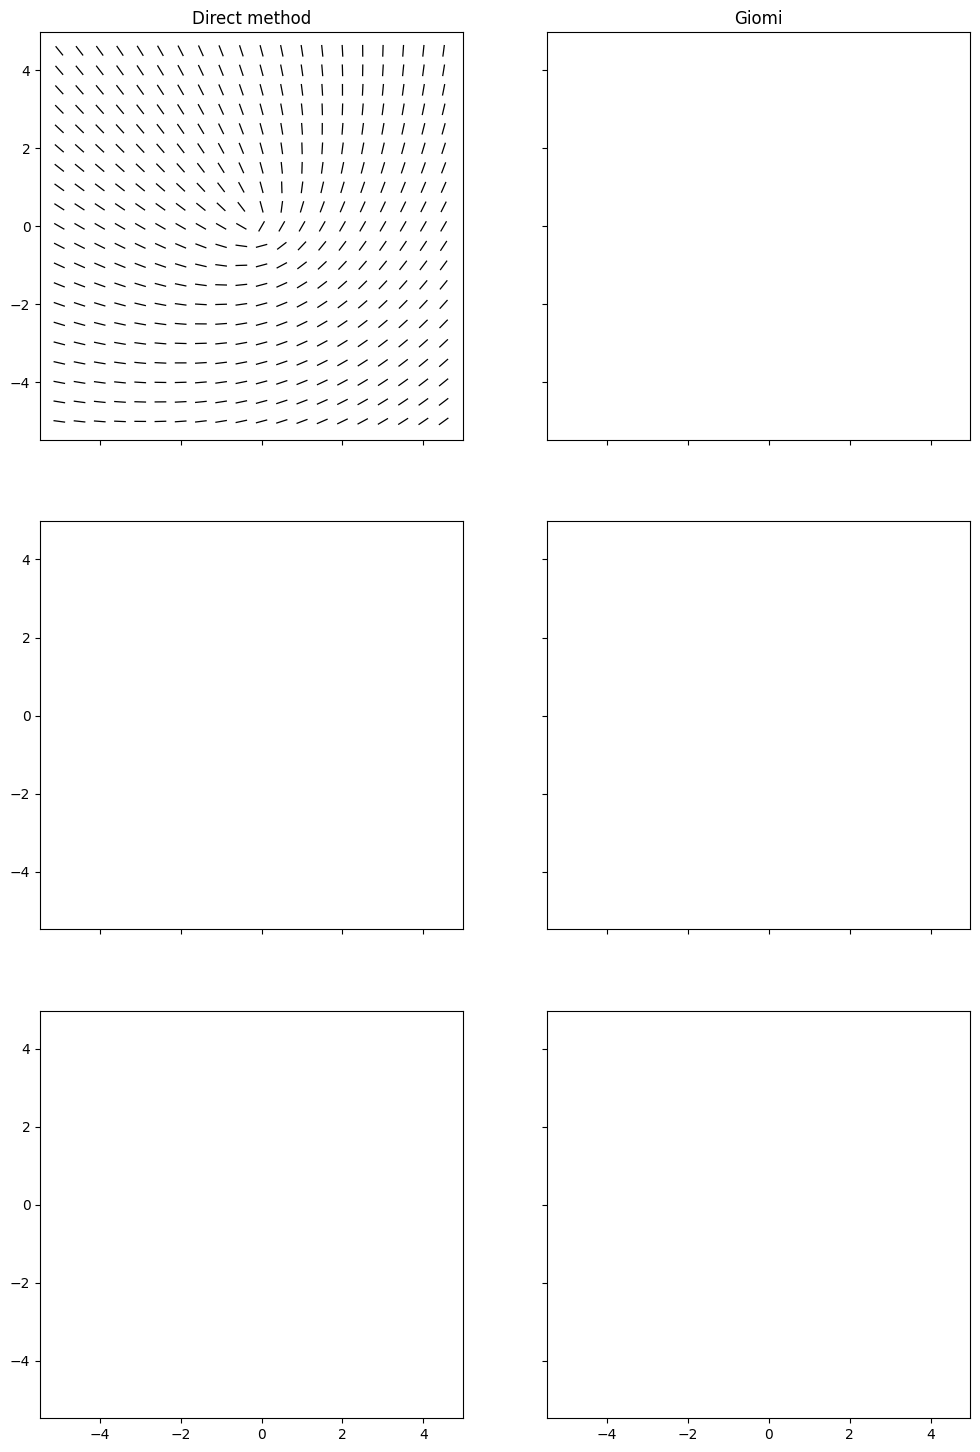

In [19]:
fig, axs = plt.subplots(3,2,figsize=(12,18),sharex=True,sharey=True)

axs[0,0].set_title('Direct method')
axs[0,1].set_title('Giomi')

charges = [1/2,-1/2,-1/2]
theta_0 = [np.pi/3,np.pi/3,0]

x = np.arange(-5,5,.5)
y = np.arange(-5,5,.5)
xx, yy = np.meshgrid(x,y)

phi = np.arctan2(yy,xx)

for i in range(len(charges)):
    theta = charges[i]*phi + theta_0[i]

    k = compute_topological_charges(theta, int_area='square', width=1, origin='lower')
    print(k.max())
    defects = localize_defects(k, x_grid=xx, y_grid=yy)
    defects['x'] = 0
    defects['y'] = 0
    for j in range(2):
        axs[i,j].quiver(xx, yy, np.cos(theta), np.sin(theta), headaxislength=0, headwidth=0, headlength=0, pivot='mid')

        if j==0:
            compute_defect_orientations(theta, defects, method='interpolation', x_grid=xx, y_grid=yy, min_sep=1, interpolation_radius=1)
        else:
            compute_defect_orientations(theta, defects)

        plushalf = defects[defects['charge']==.5]
        minushalf = defects[defects['charge']==-.5]

        axs[i,j].plot(plushalf['x'], plushalf['y'],'ro',markersize=15,label=r'+1/2 defect')
        axs[i,j].plot(plushalf['x'], plushalf['y'],'ro',markersize=15,label=r'+1/2 defect')
        axs[i,j].quiver(plushalf['x'], plushalf['y'], 
            np.cos(plushalf['ang1']), np.sin(plushalf['ang1']), 
            headaxislength=0, headwidth=0, headlength=0, color='r', scale=5)

        if 'ang2' in defects:
            for k in range(3):
                axs[i,j].quiver(minushalf['x'], minushalf['y'], 
                    np.cos(minushalf['ang'+str(k+1)]), np.sin(minushalf['ang'+str(k+1)]), 
                    headaxislength=0, headwidth=0, headlength=0, color='b', scale=6)
                axs[i,j].quiver(minushalf['x'], minushalf['y'], np.cos(minushalf['ang'+str(k+1)]), 
                    np.sin(minushalf['ang'+str(k+1)]),
                    headaxislength=0, headwidth=0, headlength=0, color='b', scale=2)

## Build asymmetric defect by hand

c:\Users\victo\nematics\nematics\vasco_scripts\defects.py:44: RuntimeWarning: divide by zero encountered in divide
  phi = np.arctan(v/u) # TO DO: catch zero exception!!


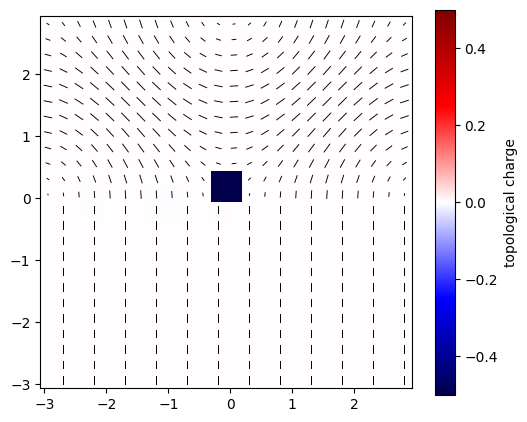

In [20]:
N = 100
R = 1

theta = np.linspace(0,2*np.pi,N,endpoint=False)
x_c = R*np.cos(theta)
y_c = R*np.sin(theta)
delta = .25
L = np.pi-.2

x_grid = np.arange(-L,L,delta)
y_grid = np.arange(-L,L,delta)
xx, yy = np.meshgrid(x_grid,y_grid)

u_lattice = np.sin(yy)
v_lattice = np.sin(xx)
u = np.copy(u_lattice)
v = np.copy(v_lattice)
v[yy<=0] = 1
u[yy<=0] = 0
phi = get_orientation_angle(u, v)
k = compute_topological_charges(phi, int_area='square', width=1, origin='lower')

fig, ax = plt.subplots(figsize=(6,5))
plt.set_cmap('seismic')
c = ax.pcolormesh(xx,yy,k,shading='auto', vmin=-.5, vmax=.5)
ax.quiver(xx, yy, u, v, headaxislength=0, headwidth=0, headlength=0, pivot='mid')
plt.colorbar(c, label='topological charge')
ax.set_box_aspect(1)

In [55]:
delta = .3
L = 2*np.pi#-.2

x_grid = np.arange(-L,L,delta)
y_grid = np.arange(-L,L,delta)
xx, yy = np.meshgrid(x_grid,y_grid)

u_lattice = np.sin(yy)
v_lattice = np.sin(xx)
u = np.copy(u_lattice)
v = -np.copy(v_lattice)


# fig, axs = plt.subplots(1,2,figsize=(16,8))
# axs[0].quiver(xx, yy, u_lattice, v_lattice, headaxislength=0, headwidth=0, headlength=0, pivot='mid')
# axs[1].quiver(xx, yy, u, v, headaxislength=0, headwidth=0, headlength=0, pivot='mid')

polar = False
t = "polar" if polar else "nematic"

phi = get_orientation_angle(u, v, type=t)
k = compute_topological_charges(phi, type=t, int_area='cell', width=3, origin='lower')

fig, ax = plt.subplots(figsize=(6,5))
plt.set_cmap('seismic')
vlim = np.max(np.abs([k.max(), k.min()]))
c = ax.pcolormesh(xx,yy,k,shading='auto', 
                  vmin=-vlim, 
                  vmax=vlim)
s = 2
ax.quiver(xx[::s,::s], yy[::s,::s], u[::s,::s], v[::s,::s], headaxislength=0, headwidth=0, headlength=0, pivot='mid')
plt.colorbar(c, label='topological charge')
ax.set_box_aspect(1)

In [49]:
%matplotlib qt

img = cv2.imread(r"C:\Users\victo\Downloads\SB_lab\BEER_DATA\MONO\cw73 45deg 0min 5\cw73 foe victor 45deg 0min 5-1406.tif", cv2.IMREAD_GRAYSCALE)
yy, xx = np.mgrid[0:img.shape[0], 0:img.shape[1]]
ori,_,_ = orientation_analysis(img, sigma=15)
# ori = cv2.imread(r"C:\Users\victo\Downloads\OJ-Orientation-6.tif", cv2.IMREAD_UNCHANGED)

fig, axs  = plt.subplots(1,1,figsize=(8,8))
s = 5
axs.imshow(img, cmap='gray')
axs.quiver(xx[::s,::s], yy[::s,::s], 
    np.cos(ori)[::s,::s], np.sin(ori)[::s,::s], 
    headaxislength=0, headwidth=0, headlength=0, color='r', scale=60, pivot='mid')

polar = False
t = "polar" if polar else "nematic"
# s = 15
phi = get_orientation_angle(np.cos(ori)[::s,::s], -np.sin(ori)[::s,::s], type=t)
k = compute_topological_charges(phi, type=t, int_area='square', width=4, origin='lower')

yy, xx = np.mgrid[0:phi.shape[0], 0:phi.shape[1]]

fig1, ax = plt.subplots(figsize=(6,5))
resized_img = cv2.resize(img, (phi.shape[0],phi.shape[1]))
ax.imshow(0*resized_img, cmap='gray')
plt.set_cmap('seismic')
vlim = np.max(np.abs([k.max(), k.min()]))
c = ax.pcolormesh(xx,yy,k,shading='auto', 
                  vmin=-1.1*vlim, 
                  vmax=1.1*vlim)
ax.quiver(xx, yy, 
    np.cos(phi), -np.sin(phi), 
    headaxislength=0, headwidth=0, headlength=0, color='r', scale=60, pivot='mid')
plt.colorbar(c, label='topological charge')
ax.set_box_aspect(1)

LinregressResult(slope=0.01902963753147393, intercept=-0.23830764308252173, rvalue=0.9939918956577463, pvalue=5.14e-322, stderr=0.00011483016358607323, intercept_stderr=0.022159841544551685)


1.0146013942576781

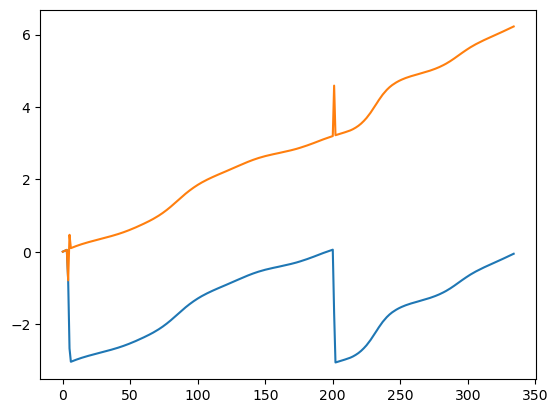

In [ ]:
%matplotlib inline
ang = pd.read_csv(r"C:\Users\victo\Downloads\test.csv").iloc[:,1]
ang = ang - ang[0]
# ang[ang<0] = ang[ang<0] + (2*np.pi)
plt.plot(ang)

unwraped = np.unwrap(ang, period=np.pi)
plt.plot(unwraped)
x = np.arange(len(unwraped))

from scipy.stats import linregress
print(linregress(x,unwraped))
(linregress(x,unwraped).slope * len(unwraped))/(2*np.pi)

In [ ]:
%matplotlib qt
s = 5
plt.imshow(ori, "hsv")
plt.plot(550,530,"+", markersize=20, alpha=.5)
xx, yy = np.mgrid[0:ori.shape[0], 0:ori.shape[1]]
plt.quiver(xx[::s,::s], yy[::s,::s], 
    np.cos(ori)[::s,::s], np.sin(ori)[::s,::s], 
    headaxislength=0, headwidth=0, headlength=0, color='k', scale=60, pivot='mid')

x, y = 550,530
# Generate points on the contour
theta = np.linspace(0, 2 * np.pi, 30)
contour_x = x + 30 * np.cos(theta)
contour_y = y + 30 * np.sin(theta)

plt.plot(contour_x,contour_y,"-m", alpha=.5)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_winding_number(orientation_field, point, radius=5, num_points=20):
    """
    Calculate the winding number around a given point in a 2D orientation field.

    Parameters:
    - orientation_field: 2D array of angles (in radians).
    - point: Tuple (x, y) of the point around which to calculate the winding number.
    - radius: Radius of the contour around the point.
    - num_points: Number of points to sample along the contour.

    Returns:
    - Winding number.
    """
    x, y = point
    winding_number = []

    # Generate points on the contour
    theta = np.linspace(0, 2 * np.pi, num_points)
    contour_x = x + radius * np.cos(theta)
    contour_y = y + radius * np.sin(theta)

    # Calculate the change in angle along the contour
    initial_angle = orientation_field[y, x]
    for i in range(num_points):
        # Get the indices in the orientation field
        ix = int(np.clip(contour_x[i], 0, orientation_field.shape[1] - 1))
        iy = int(np.clip(contour_y[i], 0, orientation_field.shape[0] - 1))

        # Get the angle at the contour point
        angle = orientation_field[iy, ix]

        # Calculate the change in angle and normalize it
        delta_angle = angle - initial_angle
        winding_number.append(delta_angle)

        initial_angle = angle

    # Normalize the winding number
    winding_number = np.sum(np.unwrap(winding_number, period=(2*np.pi)))/len(winding_number)
    winding_number /= (2 * np.pi)

    return winding_number


# Create a sample orientation field (e.g., a radial field)
# N = 100
# x = np.linspace(-1, 1, N)
# y = np.linspace(-1, 1, N)
# X, Y = np.meshgrid(x, y)
# orientation_field = np.arctan2(Y, X)  # Orientation angles in radians

orientation_field = get_orientation_angle(np.cos(ori)[::s,::s], np.sin(ori)[::s,::s])
N = orientation_field.shape[0]

# Initialize an array to store winding numbers
winding_numbers = np.zeros_like(orientation_field)

# Calculate the winding number for each pixel
for i in range(N):
    for j in range(N):
        winding_numbers[i, j] = calculate_winding_number(orientation_field, (j, i))

# Visualize the winding numbers
plt.figure(figsize=(8, 8))
plt.imshow(winding_numbers, cmap='jet')
plt.colorbar(label='Winding Number')

plt.quiver(xx, yy, 
    np.cos(phi), np.sin(phi), 
    headaxislength=0, headwidth=0, headlength=0, color='r', scale=60, pivot='mid')

plt.axis('equal')



NameError: name 'get_orientation_angle' is not defined

In [ ]:
plt.figure(figsize=(8, 8))
plt.imshow(winding_numbers, cmap='jet')
plt.colorbar(label='Winding Number')

plt.quiver(xx, yy, 
    np.cos(phi), -np.sin(phi), 
    headaxislength=0, headwidth=0, headlength=0, color='r', scale=60, pivot='mid')

plt.axis('equal')

(-0.5, 93.5, 93.5, -0.5)

7.589099e-08


(array([2.000e+00, 0.000e+00, 6.000e+01, 9.200e+01, 3.020e+02, 8.234e+03,
        6.900e+01, 7.000e+01, 1.000e+00, 6.000e+00]),
 array([-7.58909877e-08, -6.07127930e-08, -4.55345912e-08, -3.03563965e-08,
        -1.51781983e-08,  0.00000000e+00,  1.51781983e-08,  3.03563965e-08,
         4.55345912e-08,  6.07127930e-08,  7.58909877e-08]),
 <BarContainer object of 10 artists>)

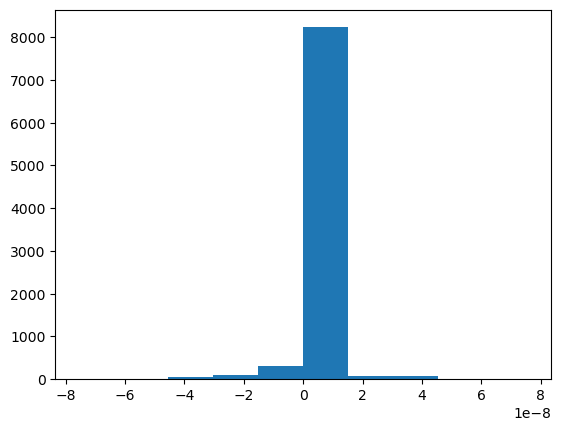

In [ ]:
%matplotlib inline
print(np.max(np.abs([k.max(), k.min()])))
plt.hist(k.ravel())

In [ ]:
defects = localize_defects(k, x_grid=xx, y_grid=yy)
defects['x'] = 0
defects['y'] = 0
compute_defect_orientations(phi, defects, method='interpolation', x_grid=xx, y_grid=yy, min_sep=1, interpolation_radius=R)
# compute_defect_orientations(phi, defects, origin='lower')
plushalf = defects[defects['charge']==.5]
minushalf = defects[defects['charge']==-.5]

defects

c:\Users\USER\anaconda3\envs\RevDx\lib\site-packages\scipy\interpolate\_fitpack_impl.py:977: RuntimeWarning: A theoretically impossible result when finding a smoothing spline
with fp = s. Probable causes: s too small or badly chosen eps.
(abs(fp-s)/s>0.001)
	kx,ky=1,1 nx,ny=26,22 m=576 fp=0.000000 s=0.000000
  warnings.warn(RuntimeWarning(_iermess2[ierm][0] + _mess))


,charge,x,y,x_ind,y_ind,ang1,ang2,ang3
0,-0.5,0,0,11,12,-1.570796,0.816814,2.324779


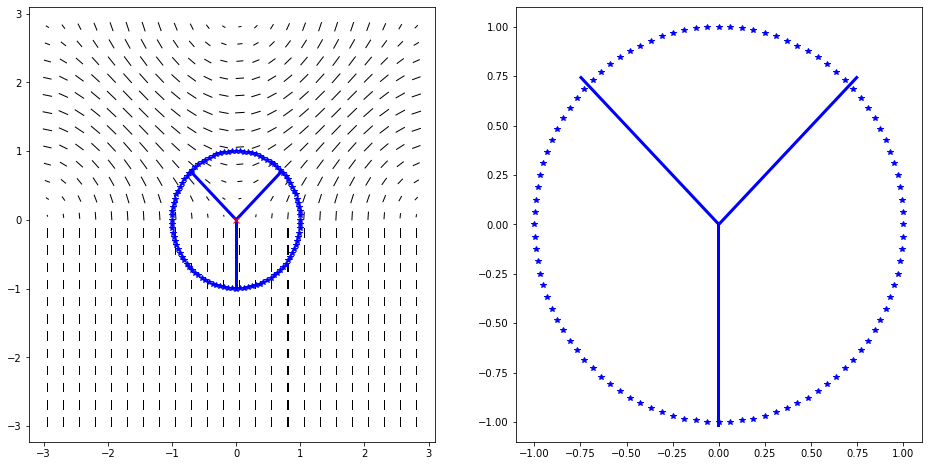

In [ ]:
x0, y0 = 0,0
fig, axs = plt.subplots(1,2,figsize=(16,8))
axs[0].quiver(xx, yy, u, v, headaxislength=0, headwidth=0, headlength=0, pivot='mid')

axs[0].plot(plushalf['x'], plushalf['y'],'ro',markersize=15,label=r'+1/2 defect')
axs[0].plot(plushalf['x'], plushalf['y'],'ro',markersize=15,label=r'+1/2 defect')
axs[0].quiver(plushalf['x'], plushalf['y'], np.cos(plushalf['ang1']), np.sin(plushalf['ang1']), headaxislength=0, headwidth=0, headlength=0, color='r', scale=50)

for i in range(3):
    axs[0].quiver(minushalf['x'], minushalf['y'], np.cos(minushalf['ang'+str(i+1)]), np.sin(minushalf['ang'+str(i+1)]), headaxislength=0, headwidth=0, headlength=0, color='b', scale=6)
    axs[1].quiver(minushalf['x'], minushalf['y'], np.cos(minushalf['ang'+str(i+1)]), np.sin(minushalf['ang'+str(i+1)]), headaxislength=0, headwidth=0, headlength=0, color='b', scale=2)

axs[0].plot(x0+x_c,y0+y_c,'b*')
axs[0].plot(x0,y0,'rx')
axs[1].plot(x0+x_c,y0+y_c,'b*')

0.5


c:\Users\USER\CODES\nematics\vasco_scripts\defects.py:44: RuntimeWarning: divide by zero encountered in true_divide
  phi = np.arctan(v/u) # TO DO: catch zero exception!!


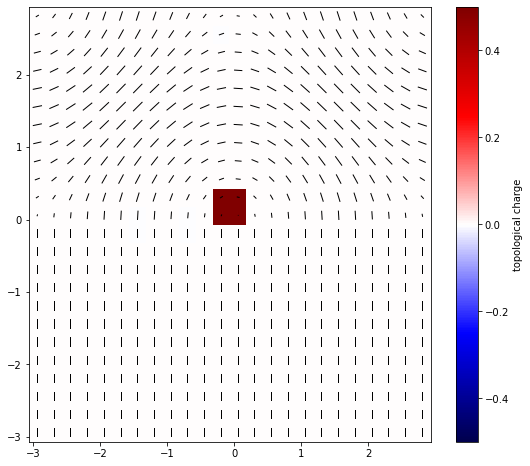

In [ ]:
phi = get_orientation_angle(u, -v)
k = compute_topological_charges(phi, int_area='square', width=1, origin='lower')
print(k.max())

fig, ax = plt.subplots(figsize=(9,8))
plt.set_cmap('seismic')
c = ax.pcolormesh(xx,yy,k,shading='auto', vmin=-.5, vmax=.5)
ax.quiver(xx, yy, u, -v, headaxislength=0, headwidth=0, headlength=0, pivot='mid')
plt.colorbar(c, label='topological charge')

In [ ]:
defects = localize_defects(k, x_grid=xx, y_grid=yy)
defects['x'] = 0
defects['y'] = 0
compute_defect_orientations(phi, defects, method='interpolation', x_grid=xx, y_grid=yy, min_sep=1, interpolation_radius=R)
# compute_defect_orientations(phi, defects, origin='lower')
plushalf = defects[defects['charge']==.5]
minushalf = defects[defects['charge']==-.5]

defects

c:\Users\USER\anaconda3\envs\RevDx\lib\site-packages\scipy\interpolate\_fitpack_impl.py:977: RuntimeWarning: A theoretically impossible result when finding a smoothing spline
with fp = s. Probable causes: s too small or badly chosen eps.
(abs(fp-s)/s>0.001)
	kx,ky=1,1 nx,ny=26,22 m=576 fp=0.000000 s=0.000000
  warnings.warn(RuntimeWarning(_iermess2[ierm][0] + _mess))


,charge,x,y,x_ind,y_ind,ang1
0,0.5,0,0,11,12,-1.570796


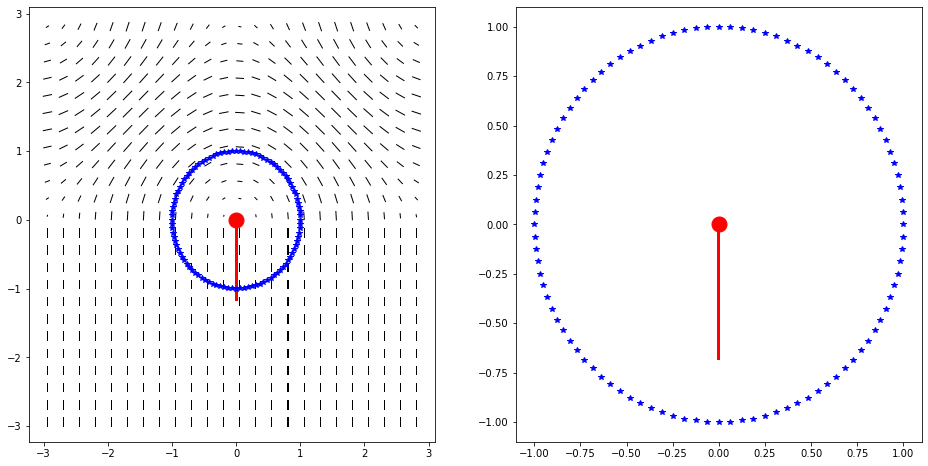

In [ ]:
x0, y0 = 0,0
fig, axs = plt.subplots(1,2,figsize=(16,8))
axs[0].quiver(xx, yy, u, -v, headaxislength=0, headwidth=0, headlength=0, pivot='mid')

axs[0].plot(plushalf['x'], plushalf['y'],'ro',markersize=15,label=r'+1/2 defect')
axs[1].plot(plushalf['x'], plushalf['y'],'ro',markersize=15,label=r'+1/2 defect')
axs[0].quiver(plushalf['x'], plushalf['y'], np.cos(plushalf['ang1']), np.sin(plushalf['ang1']), headaxislength=0, headwidth=0, headlength=0, color='r', scale=5)
axs[1].quiver(plushalf['x'], plushalf['y'], np.cos(plushalf['ang1']), np.sin(plushalf['ang1']), headaxislength=0, headwidth=0, headlength=0, color='r', scale=3)

# for i in range(3):
#     axs[0].quiver(minushalf['x'], minushalf['y'], np.cos(minushalf['ang'+str(i+1)]), np.sin(minushalf['ang'+str(i+1)]), headaxislength=0, headwidth=0, headlength=0, color='b', scale=6)
#     axs[1].quiver(minushalf['x'], minushalf['y'], np.cos(minushalf['ang'+str(i+1)]), np.sin(minushalf['ang'+str(i+1)]), headaxislength=0, headwidth=0, headlength=0, color='b', scale=2)

axs[0].plot(x0+x_c,y0+y_c,'b*')
axs[0].plot(x0,y0,'rx')
axs[1].plot(x0+x_c,y0+y_c,'b*')

In [ ]:
delta = .4
L = 4*np.pi

x_grid = np.arange(0,L,delta)
y_grid = np.arange(0,L,delta)
xx, yy = np.meshgrid(x_grid,y_grid)

u_lattice = np.cos(yy)
v_lattice = np.cos(xx)